In [2]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


데이터를 불러오고 그래프를 그립니다... 🎨


C:\Users\pc\AppData\Local\Temp\ipykernel_15744\2805067518.py:34: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_15744\2805067518.py:34: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


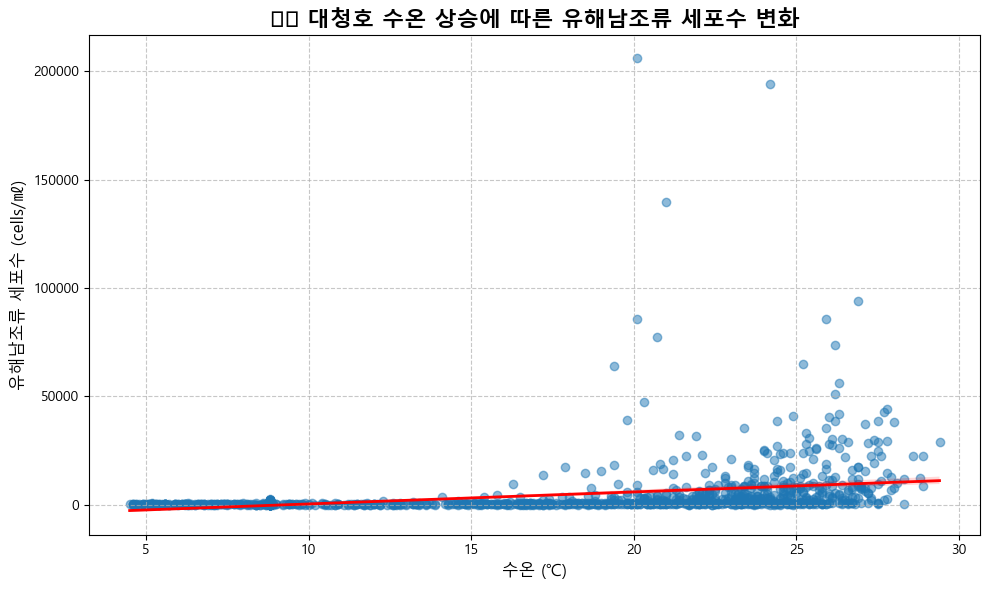

C:\Users\pc\AppData\Local\Temp\ipykernel_15744\2805067518.py:52: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


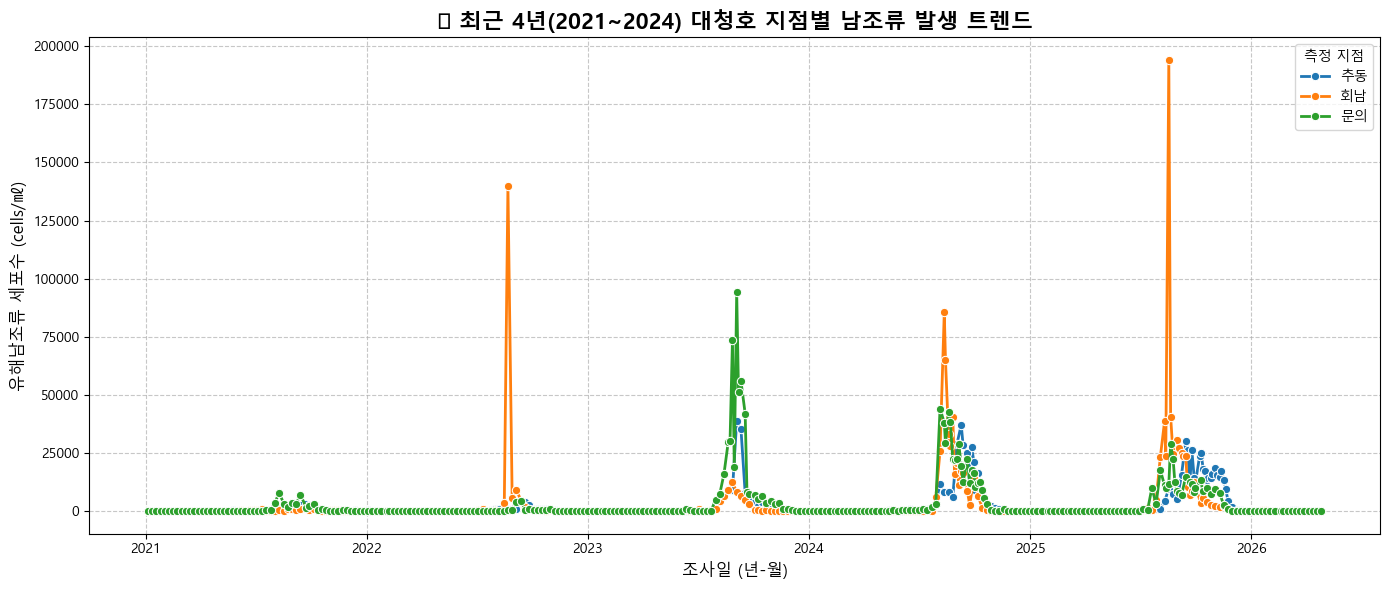

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# ⚙️ 한글 폰트 깨짐 방지 설정 (윈도우 전용)
# ---------------------------------------------------------
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

print("데이터를 불러오고 그래프를 그립니다... 🎨")

# 1. 완성된 마스터 데이터 불러오기
df = pd.read_csv('./data/대청호 조류 전처리 완료 통합 데이터.csv')

# 날짜 형식으로 다시 변환 (그래프 그릴 때 시간 순서대로 나오게 하려고)
df['조사일'] = pd.to_datetime(df['조사일'])

# ---------------------------------------------------------
# 📈 [그래프 A] 수온과 유해남조류 세포수의 관계 (산점도 & 추세선)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# 남조류가 0인 데이터가 너무 많아서, 실제로 발생한 날(0 초과)만 걸러서 보자!
df_algae = df[df['유해남조류 세포수 (cells/㎖)'] > 0]

sns.regplot(x='수온(℃)', y='유해남조류 세포수 (cells/㎖)', data=df_algae, 
            scatter_kws={'alpha':0.5, 'color':'#1f77b4'}, 
            line_kws={'color':'red', 'linewidth':2})

plt.title('🌡️ 대청호 수온 상승에 따른 유해남조류 세포수 변화', fontsize=16, fontweight='bold')
plt.xlabel('수온 (℃)', fontsize=12)
plt.ylabel('유해남조류 세포수 (cells/㎖)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 📉 [그래프 B] 최근 3년 지점별 남조류 발생 트렌드 (시계열)
# ---------------------------------------------------------
# 10년 치를 다 그리면 너무 빽빽하니까 2021년 이후 데이터만 잘라서 보자!
df_recent = df[df['조사일'].dt.year >= 2021]

plt.figure(figsize=(14, 6))
sns.lineplot(x='조사일', y='유해남조류 세포수 (cells/㎖)', hue='채수위치', 
             data=df_recent, marker='o', linewidth=2)

plt.title('📅 최근 4년(2021~2024) 대청호 지점별 남조류 발생 트렌드', fontsize=16, fontweight='bold')
plt.xlabel('조사일 (년-월)', fontsize=12)
plt.ylabel('유해남조류 세포수 (cells/㎖)', fontsize=12)
plt.legend(title='측정 지점')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()